In [41]:
import json
import os
import numpy as np
import pandas as pd
from collections import defaultdict
import matplotlib.pyplot as plt
import seaborn as sns

In [47]:
def load_results(path='../results'):
    keys = ["test_score", "dev_score", "best_instruction"]
    results = []
    for dirname in os.listdir(path):
        if dirname.endswith('.json'):
            continue
        method_path = os.path.join(path, dirname)
        for task in os.listdir(method_path):
            task_path = os.path.join(method_path, task)
            for seed in os.listdir(task_path):
                if seed.endswith('.json'):
                    seed_path = os.path.join(task_path, seed)
                    with open(seed_path, 'r') as fh:
                        seed_res = json.load(fh)
                    obj = {
                        "name": dirname, 
                        "seed": seed.replace(".json", ""), 
                        **{k:v for k,v in seed_res.items() if k in keys},
                        **seed_res['args'],
                        "run_path": seed_path
                    }
                    results.append(obj)
    results_df = pd.DataFrame(results)

    name_map = {
        "vicuna_gpt-3.5-turbo": "InstructZero",
        "moreiters_vicuna_gpt-3.5-turbo": "InstructZero (more iters)",
        "nocoupled_vicuna_gpt-3.5-turbo": "Standard kernel",
        "noprompt-temp1_vicuna_gpt-3.5-turbo": "Repeated sampling (no BO)",
        "randprompt_vicuna_gpt-3.5-turbo": "Random soft-prompts"
    }
    results_df["name"] = results_df.name.map(lambda x: name_map.get(x, x))
    return results_df

In [48]:
results_df = load_results()

In [49]:
condition = (results_df.model_name == 'vicuna') & (results_df.bbox_model == 'gpt-3.5-turbo')

In [29]:
results_df[condition].groupby('name').count()

,seed,test_score,dev_score,best_instruction,task,random_proj,intrinsic_dim,n_prompt_tokens,HF_cache_dir,alpha,...,random_prompt,coupled_kernel,do_sample,bbox_model,bbox_cache,n_init,batch_size,n_iterations,temperature,run_path
name,,,,,,,,,,,,,,,,,,,,,
"High iterations, low batch-size",18,18,18,18,18,18,18,18,18,18,...,18,18,18,18,18,18,18,18,18,18
InstructZero,18,18,18,18,18,18,18,18,18,18,...,18,18,18,18,18,18,18,18,18,18
Random soft-prompts,18,18,18,18,18,18,18,18,18,18,...,18,18,18,18,18,18,18,18,18,18
Repeated sampling (no BO),18,18,18,18,18,18,18,18,18,18,...,18,18,18,18,18,18,18,18,18,18
Standard kernel,18,18,18,18,18,18,18,18,18,18,...,18,18,18,18,18,18,18,18,18,18


In [62]:
results_df[condition].groupby('name')[['dev_score', 'test_score']].agg(['mean', 'std'])

dev_score           test_score          
                               mean       std       mean       std
name                                                              
InstructZero               0.751006  0.221665   0.585606  0.255449
InstructZero (more iters)  0.732056  0.226859   0.542983  0.266058
Random soft-prompts        0.701922  0.267116   0.515889  0.298349
Repeated sampling (no BO)  0.746617  0.256133   0.629539  0.285670
Standard kernel            0.732356  0.251116   0.613478  0.275962

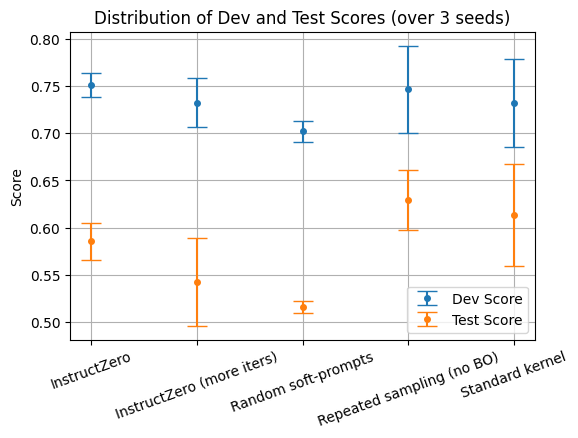

In [100]:
# Calculate mean and std for each group
_df = results_df[condition].groupby(['name', 'seed'])[['dev_score', 'test_score']].mean().reset_index()
grouped = _df.groupby('name')[['dev_score', 'test_score']].agg(['mean', 'std'])

# Plot
fig, ax = plt.subplots(figsize=(6, 4))

# Mean and Std for dev_score
ax.errorbar(grouped.index, grouped['dev_score']['mean'], yerr=grouped['dev_score']['std'], 
            fmt='o', markersize=4, capsize=7, label='Dev Score')

# Mean and Std for test_score
ax.errorbar(grouped.index, grouped['test_score']['mean'], yerr=grouped['test_score']['std'], 
            fmt='o', markersize=4, capsize=7, label='Test Score')

# Customize the plot
ax.set_title(f"Distribution of Dev and Test Scores (over {len(_df.seed.unique())} seeds)")
ax.set_xlabel(None)
plt.xticks(rotation=20)
ax.set_ylabel("Score")
ax.legend()
ax.grid()

plt.show()

In [75]:
results_df[condition].groupby(['name', 'seed'])[['dev_score', 'test_score']].mean().reset_index()

,name,seed,dev_score,test_score
0,InstructZero,0,0.765950,0.608383
1,InstructZero,1,0.740950,0.571283
2,InstructZero,2,0.746117,0.577150
3,InstructZero (more iters),0,0.732617,0.596717
4,InstructZero (more iters),1,0.757617,0.515283
5,InstructZero (more iters),2,0.705933,0.516950
6,Random soft-prompts,0,0.690950,0.516283
7,Random soft-prompts,1,0.701667,0.509133
8,Random soft-prompts,2,0.713150,0.522250
9,Repeated sampling (no BO),0,0.699283,0.593083


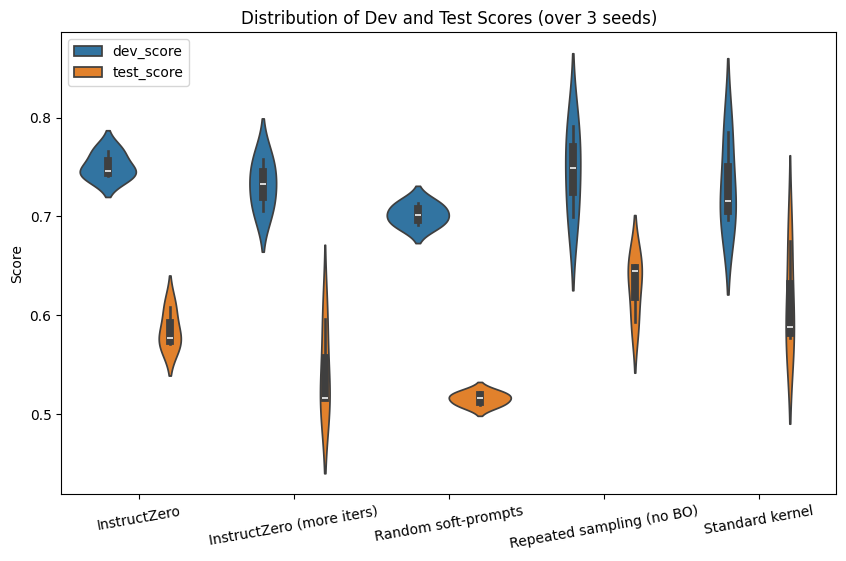

In [91]:
_df = results_df[condition].groupby(['name', 'seed'])[['dev_score', 'test_score']].mean().reset_index()
df_melted = _df.melt(id_vars="name", value_vars=["dev_score", "test_score"], var_name="score_type", value_name="score")

# Plot
plt.figure(figsize=(10, 6))
sns.violinplot(data=df_melted, x="name", y="score", hue="score_type", split=False)

# Customize
plt.title(f"Distribution of Dev and Test Scores (over {len(_df.seed.unique())} seeds)")
plt.xlabel(None)
plt.ylabel("Score")
plt.legend()  # title="Score Type")
plt.xticks(rotation=10)
plt.show()

In [32]:
results_df[condition].groupby(['name', 'task'])[['dev_score', 'test_score']].mean()

dev_score  test_score
name                            task                                     
High iterations, low batch-size informal_to_formal   0.609000    0.524567
                                letters_list         1.000000    0.980000
                                odd_one_out          1.000000    0.613333
                                second_word_letter   0.633333    0.540000
                                synonyms             0.416667    0.170000
                                word_sorting         0.733333    0.430000
InstructZero                    informal_to_formal   0.606033    0.530300
                                letters_list         1.000000    0.980000
                                odd_one_out          1.000000    0.646667
                                second_word_letter   0.666667    0.450000
                                synonyms             0.416667    0.196667
                                word_sorting         0.816667    0.710000
Random soft-prompts             informal_to_formal   0.594867    0.588667
                                letters_list         1.000000    0.980000
                                odd_one_out          1.000000    0.620000
                                second_word_letter   0.433333    0.280000
                                synonyms             0.366667    0.113333
                                word_sorting         0.816667    0.513333
Repeated sampling (no BO)       informal_to_formal   0.613033    0.563900
                                letters_list         1.000000    1.000000
                                odd_one_out          1.000000    0.686667
                                second_word_letter   0.766667    0.753333
                                synonyms             0.333333    0.130000
                                word_sorting         0.766667    0.643333
Standard kernel                 informal_to_formal   0.594133    0.557533
                                letters_list         1.000000    0.980000
                                odd_one_out          1.000000    0.633333
                                second_word_letter   0.666667    0.706667
                                synonyms             0.366667    0.120000
                                word_sorting         0.766667    0.683333